# Accumulator Probe — Final Experiments

Loads the saved perturbation checkpoint and runs:
- Cross-language generalization (Java, C++, C, C#, JS, PHP)
- Multi-model comparison
- Cross-model transfer matrix
- All CSV saves

In [ ]:
import torch, numpy as np, matplotlib.pyplot as plt, re, ast, os, json, pickle, csv
import keyword, builtins, warnings
from collections import defaultdict
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from numpy.linalg import norm
warnings.filterwarnings('ignore')

DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'
RESULTS_DIR = '../results/accumulator'
CKPT_DIR    = f'{RESULTS_DIR}/checkpoints'
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f'Device: {DEVICE}')

## Load Model

In [ ]:
MODEL_NAME = 'Qwen/Qwen2.5-1.5B'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModel.from_pretrained(MODEL_NAME, output_hidden_states=True, trust_remote_code=True)
model.eval().to(DEVICE)

NUM_LAYERS  = model.config.num_hidden_layers
HIDDEN_SIZE = model.config.hidden_size
_probe_ids      = tokenizer('x', return_tensors='pt')['input_ids'][0].tolist()
LEADING_SPECIAL = len(_probe_ids) - len(tokenizer.tokenize('x'))
print(f'Layers={NUM_LAYERS}  Hidden={HIDDEN_SIZE}  LeadingSpecial={LEADING_SPECIAL}')

## Load Data

In [ ]:
XLCOST_ROOT  = '/Applications/Projects/Algoverse/Coding/XLCoST_data'
NL2CODE_PROG = os.path.join(XLCOST_ROOT, 'retrieval', 'nl2code_search', 'program_level')

def reconstruct_code(tokens):
    indent, lines, cur = 0, [], []
    for t in tokens:
        if t == 'NEW_LINE':  lines.append('    '*indent + ' '.join(cur)); cur = []
        elif t == 'INDENT':  indent += 1
        elif t == 'DEDENT':  indent = max(0, indent-1)
        else:                cur.append(t)
    if cur: lines.append('    '*indent + ' '.join(cur))
    return '\n'.join(lines).strip()

def load_programs(lang, split='train', n=500):
    path = os.path.join(NL2CODE_PROG, lang, f'{split}.jsonl')
    if not os.path.exists(path): raise FileNotFoundError(path)
    progs = []
    with open(path) as f:
        for line in f:
            if len(progs) >= n: break
            rec  = json.loads(line)
            toks = rec.get('code_tokens', rec.get('docstring_tokens', []))
            if toks: progs.append(reconstruct_code(toks))
    return progs

RAW_PROGRAMS = load_programs('Python', n=500)
print(f'Loaded {len(RAW_PROGRAMS)} Python programs')

## Core Functions

In [ ]:
PYTHON_PROTECTED = set(keyword.kwlist) | set(dir(builtins)) | {'self','cls','None','True','False'}

def get_accumulator_names(code):
    accumulators = set()
    try: tree = ast.parse(code)
    except SyntaxError: return accumulators
    loop_vars = set()
    for node in ast.walk(tree):
        if isinstance(node, ast.For):
            for n in ast.walk(node.target):
                if isinstance(n, ast.Name): loop_vars.add(n.id)
    index_names = set()
    for node in ast.walk(tree):
        if isinstance(node, ast.Subscript):
            slc = node.slice
            if isinstance(slc, ast.Index): slc = slc.value
            if isinstance(slc, ast.Name): index_names.add(slc.id)
    _APPEND = {'append','extend','add','update'}
    for node in ast.walk(tree):
        if not isinstance(node, (ast.For, ast.While)): continue
        for stmt in ast.walk(node):
            if isinstance(stmt, ast.AugAssign) and isinstance(stmt.target, ast.Name):
                n = stmt.target.id
                if n not in loop_vars and n not in index_names and n != '_':
                    accumulators.add(n)
            elif (isinstance(stmt, ast.Expr) and isinstance(stmt.value, ast.Call)
                  and isinstance(stmt.value.func, ast.Attribute)
                  and stmt.value.func.attr in _APPEND
                  and isinstance(stmt.value.func.value, ast.Name)):
                n = stmt.value.func.value.id
                if n not in loop_vars and n not in index_names and n != '_':
                    accumulators.add(n)
    return accumulators


def label_tokens(code, target_names):
    if not target_names: return [], []
    tokens, labels = tokenizer.tokenize(code), []
    for tok in tokens:
        clean   = tok.lstrip('Ġ▁Ā').lstrip('##')
        matched = not tok.startswith('##') and (clean in target_names or clean.strip('[]().,;:') in target_names)
        labels.append(1 if matched else 0)
    return tokens, labels


MAX_SEQ_LEN = 512

def extract_hidden_states(dataset):
    all_hidden, all_labels, all_toks = defaultdict(list), [], []
    with torch.no_grad():
        for s in tqdm(dataset, desc='Extracting hidden states', leave=True):
            enc = tokenizer(s['code'], return_tensors='pt', truncation=True,
                            max_length=MAX_SEQ_LEN, padding=False).to(DEVICE)
            enc_len      = enc['input_ids'].shape[1] - LEADING_SPECIAL
            labels_trunc = s['labels'][:enc_len]
            for li, hs in enumerate(model(**enc).hidden_states):
                all_hidden[li].extend(hs[0, LEADING_SPECIAL:LEADING_SPECIAL+len(labels_trunc)].cpu().float().numpy())
            all_labels.extend(labels_trunc)
            all_toks.extend(s['tokens'][:enc_len])
    return {k: np.array(v) for k,v in all_hidden.items()}, np.array(all_labels), all_toks


def train_probes(hidden_by_layer, labels, test_size=0.2, rs=42):
    n = len(labels)
    tr, te = train_test_split(np.arange(n), test_size=test_size, random_state=rs, stratify=labels)
    results = {}
    for li in tqdm(sorted(hidden_by_layer), desc='Training probes', leave=True):
        X = hidden_by_layer[li]
        clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=rs, C=1.0)
        clf.fit(X[tr], labels[tr])
        results[li] = {
            'probe':     clf,
            'train_acc': accuracy_score(labels[tr], clf.predict(X[tr])),
            'test_acc':  accuracy_score(labels[te], clf.predict(X[te])),
            'train_f1':  f1_score(labels[tr], clf.predict(X[tr]),  average='macro', zero_division=0),
            'test_f1':   f1_score(labels[te], clf.predict(X[te]),  average='macro', zero_division=0),
            'test_idx':  te,
        }
    return results

print('Core functions defined.')

## Load Checkpoint (Perturbation Results)

In [11]:
with open(f'{CKPT_DIR}/all_results.pkl', 'rb') as f:
    all_results = pickle.load(f)
with open(f'{CKPT_DIR}/all_labels.pkl', 'rb') as f:
    all_labels = pickle.load(f)

layers = sorted(next(iter(all_results.values())).keys())
print(f'Loaded strategies: {list(all_results.keys())}')
print(f'Layers: {len(layers)}  ({layers[0]} … {layers[-1]})')

print('\nPerturbation results summary:')
base_best_f1  = max(all_results['baseline'][l]['test_f1']  for l in layers)
base_best_acc = max(all_results['baseline'][l]['test_acc'] for l in layers)
print(f'{"Strategy":18s}  {"Best L":>7}  {"Test F1":>8}  {"Δ F1":>8}')
print('-'*50)
for s, res in all_results.items():
    bl = max(res, key=lambda l: res[l]['test_f1'])
    f1 = res[bl]['test_f1']
    delta = f'{f1-base_best_f1:+.3f}' if s != 'baseline' else '—'
    print(f'{s:18s}  {bl:>7d}  {f1:>8.3f}  {delta:>8}')

Loaded strategies: ['baseline', 'random_nouns', 'single_chars', 'all_same', 'numeric_vars', 'misleading']
Layers: 29  (0 … 28)

Perturbation results summary:
Strategy             Best L   Test F1      Δ F1
--------------------------------------------------
baseline                  9     0.893         —
random_nouns             10     0.870    -0.023
single_chars              9     0.840    -0.053
all_same                  5     0.969    +0.076
numeric_vars              3     0.986    +0.093
misleading                9     0.972    +0.079


## Cross-Language Generalization

In [13]:
_C_KW    = {'int','long','char','short','float','double','unsigned','void','size_t','bool','true','false','null','NULL'}
_JAVA_KW = {'int','long','char','byte','short','boolean','float','double','String','Integer','Long','Object','null','true','false'}
_CS_KW   = {'int','long','char','byte','short','bool','float','double','string','object','null','true','false','var'}
_JS_KW   = {'undefined','null','true','false','NaN','Infinity','length','prototype','constructor'}

_AUG_RE  = re.compile(r'\b([a-zA-Z_]\w*)\s*(?:\+=|-=|\*=|/=|\|=|&=|\^=)')
_INC_RE  = re.compile(r'\b([a-zA-Z_]\w*)\s*(?:\+\+|--)')
_APP_RE  = re.compile(r'\b([a-zA-Z_]\w*)\.(?:add|push|append|extend|offer)\s*\(')

def _accum_re(code, ex=None):
    c = set()
    for p in [_AUG_RE, _INC_RE, _APP_RE]: [c.add(m.group(1)) for m in p.finditer(code)]
    return c - (ex or set())

LANG_EXTRACTORS = {
    'Java':       lambda c: _accum_re(c, _JAVA_KW),
    'C++':        lambda c: _accum_re(c, _C_KW),
    'C':          lambda c: _accum_re(c, _C_KW),
    'C#':         lambda c: _accum_re(c, _CS_KW),
    'Javascript': lambda c: _accum_re(c, _JS_KW),
    'PHP':        lambda c: _accum_re(re.sub(r'\$([a-zA-Z_]\w*)', r'\1', c)),
}
LANG_COLORS = {'Java':'#FF9800','C++':'#2196F3','C':'#4CAF50','C#':'#9C27B0','Javascript':'#F44336','PHP':'#795548'}

py_results = all_results['baseline']
lang_cross, lang_cosine_cl, lang_results_cl = {}, {}, {}

for lang, extractor in LANG_EXTRACTORS.items():
    print(f'\n{"─"*50}  {lang}')
    try: programs = load_programs(lang, n=300)
    except FileNotFoundError as e: print(f'  Skip — {e}'); continue

    data, skipped = [], 0
    for code in programs:
        names = extractor(code)
        if not names: skipped += 1; continue
        toks, labs = label_tokens(code, names)
        if toks and sum(labs) > 0:
            data.append({'code': code, 'tokens': toks, 'labels': labs, 'target_names': names})
        else: skipped += 1
    print(f'  {len(data)} programs  ({skipped} skipped)')
    if not data: continue

    lh, ll, _ = extract_hidden_states(data)
    print(f'  tokens={len(ll):,}  pos={int(sum(ll)):,}')

    lang_cross[lang] = {li: accuracy_score(ll, py_results[li]['probe'].predict(lh[li]))
                        for li in sorted(py_results) if li in lh}

    if len(ll) >= 20 and sum(ll) >= 5:
        lp = train_probes(lh, ll)
        lang_results_cl[lang] = lp
        lang_cosine_cl[lang]  = [
            np.dot(py_results[li]['probe'].coef_[0], lp[li]['probe'].coef_[0]) /
            (norm(py_results[li]['probe'].coef_[0]) * norm(lp[li]['probe'].coef_[0]))
            for li in sorted(py_results) if li in lp
        ]
        best_l = max(lp, key=lambda l: lp[l]['test_f1'])
        print(f'  In-domain F1={lp[best_l]["test_f1"]:.3f} (L{best_l})  '
              f'Cross-acc={max(lang_cross[lang].values()):.3f}')

print('\nCross-language done:', list(lang_cross.keys()))


──────────────────────────────────────────────────  Java
  208 programs  (92 skipped)


Extracting hidden states: 100%|██████████| 208/208 [17:57<00:00,  5.18s/it]


  tokens=46,972  pos=2,625


Training probes: 100%|██████████| 29/29 [05:11<00:00, 10.75s/it]


  In-domain F1=0.952 (L9)  Cross-acc=0.948

──────────────────────────────────────────────────  C++
  204 programs  (96 skipped)


...

  In-domain F1=0.947 (L9)  Cross-acc=0.931

──────────────────────────────────────────────────  PHP
  190 programs  (110 skipped)


Extracting hidden states: 100%|██████████| 190/190 [16:03<00:00,  5.07s/it]


  tokens=42,194  pos=2,733


Training probes: 100%|██████████| 29/29 [04:06<00:00,  8.52s/it]

  In-domain F1=0.956 (L14)  Cross-acc=0.940

Cross-language done: ['Java', 'C++', 'C', 'C#', 'Javascript', 'PHP']


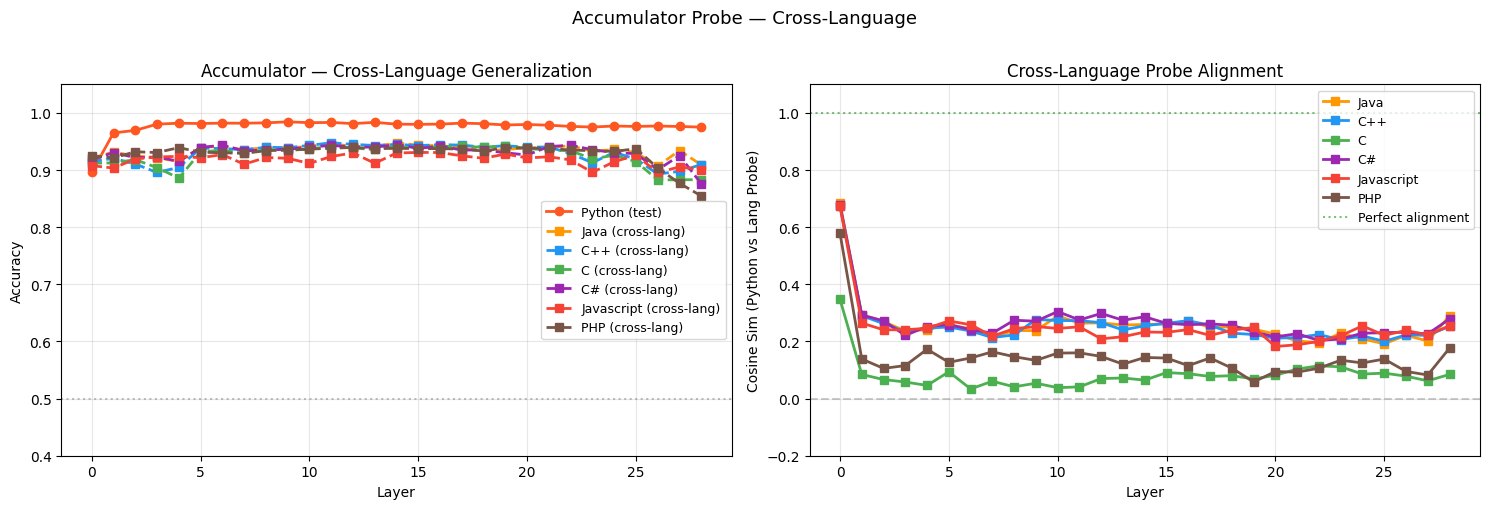

Saved cross_language_accumulator.png


In [14]:
if lang_cross:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    ax = axes[0]
    ax.plot(layers, [py_results[l]['test_acc'] for l in layers],
            marker='o', color='#FF5722', linewidth=2, label='Python (test)')
    for lang, ca in lang_cross.items():
        ll = sorted(ca)
        ax.plot(ll, [ca[l] for l in ll], marker='s', linestyle='--',
                linewidth=2, color=LANG_COLORS[lang], label=f'{lang} (cross-lang)')
    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
    ax.set_xlabel('Layer'); ax.set_ylabel('Accuracy'); ax.set_ylim(0.4, 1.05)
    ax.set_title('Accumulator — Cross-Language Generalization'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

    ax = axes[1]
    for lang, sims in lang_cosine_cl.items():
        ll = sorted(py_results)[:len(sims)]
        ax.plot(ll, sims, marker='s', linewidth=2, color=LANG_COLORS[lang], label=lang)
    ax.axhline(1.0, color='green', linestyle=':', alpha=0.5, label='Perfect alignment')
    ax.axhline(0.0, color='gray',  linestyle='--', alpha=0.4)
    ax.set_xlabel('Layer'); ax.set_ylabel('Cosine Sim (Python vs Lang Probe)')
    ax.set_ylim(-0.2, 1.1); ax.set_title('Cross-Language Probe Alignment')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    plt.suptitle('Accumulator Probe — Cross-Language', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/cross_language_accumulator.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved cross_language_accumulator.png')

## Multi-Model Comparison

In [15]:
from transformers import AutoTokenizer as _Tok, AutoModel as _Mdl

ADDITIONAL_MODELS = {
    'CodeBERT':     'microsoft/codebert-base',
    'RoBERTa':      'roberta-base',
    'Qwen2.5-0.5B': 'Qwen/Qwen2.5-0.5B',
}

def _run_model(model_name, dataset):
    tok = _Tok.from_pretrained(model_name, trust_remote_code=True)
    if tok.pad_token_id is None: tok.pad_token = tok.eos_token
    mdl = _Mdl.from_pretrained(model_name, output_hidden_states=True, trust_remote_code=True)
    mdl.eval().to(DEVICE)
    leading = len(tok('x', return_tensors='pt')['input_ids'][0]) - len(tok.tokenize('x'))

    relabeled = []
    for s in dataset:
        toks = tok.tokenize(s['code']); labs = []
        for t in toks:
            clean = t.lstrip('Ġ▁Ā').lstrip('##')
            labs.append(1 if (not t.startswith('##') and
                              (clean in s['target_names'] or clean.strip('[]().,;:') in s['target_names'])) else 0)
        if toks and sum(labs) > 0: relabeled.append({**s, 'tokens': toks, 'labels': labs})

    all_h, all_l = defaultdict(list), []
    with torch.no_grad():
        for s in tqdm(relabeled, desc=f'  {model_name.split("/")[-1]}', leave=False):
            enc = tok(s['code'], return_tensors='pt', truncation=True,
                      max_length=512, padding=False).to(DEVICE)
            enc_len = enc['input_ids'].shape[1] - leading
            labs_t  = s['labels'][:enc_len]
            for li, hs in enumerate(mdl(**enc).hidden_states):
                all_h[li].extend(hs[0, leading:leading+len(labs_t)].cpu().float().numpy())
            all_l.extend(labs_t)

    del mdl
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    h = {k: np.array(v) for k,v in all_h.items()}
    return train_probes(h, np.array(all_l)), h, np.array(all_l)


# Build baseline dataset (original Python code + accumulator labels)
_bds = []
for code in RAW_PROGRAMS:
    names = get_accumulator_names(code)
    if not names: continue
    toks, labs = label_tokens(code, names)
    if toks and sum(labs) > 0:
        _bds.append({'code': code, 'tokens': toks, 'labels': labs, 'target_names': names})
print(f'Baseline dataset: {len(_bds)} programs')

# Extract Qwen2.5-1.5B hidden states (needed for cross-model transfer)
print('\nExtracting Qwen2.5-1.5B hidden states...')
_qwen_h, _qwen_l, _ = extract_hidden_states(_bds)

mm_results = {'Qwen2.5-1.5B': all_results['baseline']}
mm_hidden  = {'Qwen2.5-1.5B': _qwen_h}
mm_labels  = {'Qwen2.5-1.5B': _qwen_l}

for nick, mname in ADDITIONAL_MODELS.items():
    print(f'\n{"─"*50}  {nick}')
    try:
        res, h, lbs = _run_model(mname, _bds)
        mm_results[nick] = res; mm_hidden[nick] = h; mm_labels[nick] = lbs
        best_l = max(res, key=lambda l: res[l]['test_f1'])
        print(f'  L{best_l}  F1={res[best_l]["test_f1"]:.3f}  Acc={res[best_l]["test_acc"]:.3f}')
    except Exception as e:
        print(f'  FAILED: {e}')

print('\nModels done:', list(mm_results.keys()))

Baseline dataset: 181 programs

Extracting Qwen2.5-1.5B hidden states...


Extracting hidden states: 100%|██████████| 181/181 [13:41<00:00,  4.54s/it]



──────────────────────────────────────────────────  CodeBERT


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 29407.27it/s]
Token indices sequence length is longer than the specified maximum sequence length for this model (513 > 512). Running this sequence through the model will result in indexing errors
Training probes: 100%|██████████| 13/13 [00:52<00:00,  4.05s/it]  


  L9  F1=0.781  Acc=0.971

──────────────────────────────────────────────────  RoBERTa


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 7243.22it/s]
RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Token indices sequence length is longer than the specified maximum sequence length for this model (513 > 512). Running this sequence through the model will res

  L10  F1=0.797  Acc=0.973

──────────────────────────────────────────────────  Qwen2.5-0.5B


Training probes: 100%|██████████| 25/25 [03:36<00:00,  8.65s/it] 


  L11  F1=0.853  Acc=0.976

Models done: ['Qwen2.5-1.5B', 'CodeBERT', 'RoBERTa', 'Qwen2.5-0.5B']


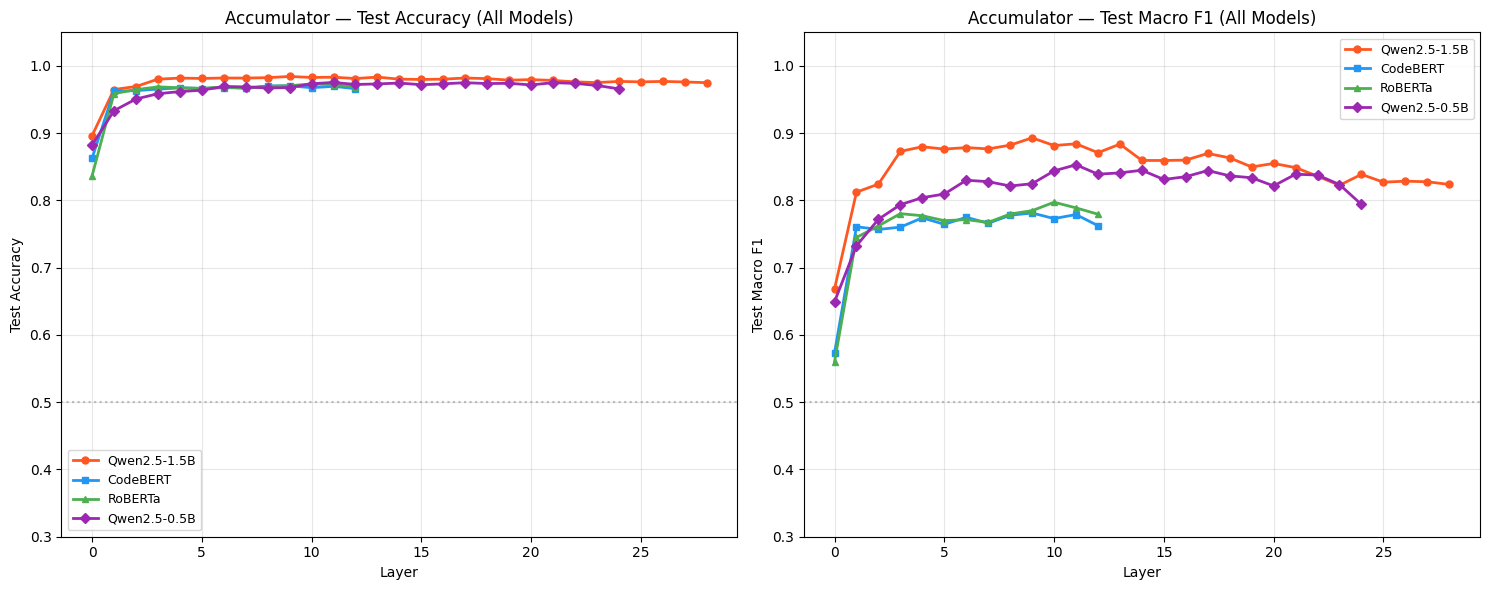


Model                       Best L   Test Acc   Test F1
-------------------------------------------------------
Qwen2.5-1.5B                     9      0.984     0.893
CodeBERT                         9      0.971     0.781
RoBERTa                         10      0.973     0.797
Qwen2.5-0.5B                    11      0.976     0.853


In [16]:
MC = ['#FF5722','#2196F3','#4CAF50','#9C27B0','#FF9800','#00BCD4']
MM = ['o','s','^','D','P','X']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, metric, ylabel in zip(axes, ['test_acc','test_f1'], ['Test Accuracy','Test Macro F1']):
    for i, (nick, res) in enumerate(mm_results.items()):
        model_layers = sorted(res.keys())  # each model has its own layer count
        ax.plot(model_layers, [res[l][metric] for l in model_layers],
                marker=MM[i%len(MM)], color=MC[i%len(MC)], linewidth=2, markersize=5, label=nick)
    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
    ax.set_xlabel('Layer'); ax.set_ylabel(ylabel); ax.set_ylim(0.3, 1.05)
    ax.set_title(f'Accumulator — {ylabel} (All Models)'); ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/multi_model_accumulator.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n{"Model":25s}  {"Best L":>7}  {"Test Acc":>9}  {"Test F1":>8}')
print('-' * 55)
for nick, res in mm_results.items():
    bl = max(res, key=lambda l: res[l]['test_f1'])
    print(f'{nick:25s}  {bl:>7d}  {res[bl]["test_acc"]:>9.3f}  {res[bl]["test_f1"]:>8.3f}')

## Cross-Model Transfer Matrix

In [ ]:
nicks = list(mm_results.keys()); N = len(nicks)
xfer  = np.full((N, N), np.nan)

for i, src in enumerate(nicks):
    for j, tgt in enumerate(nicks):
        if src not in mm_hidden or tgt not in mm_hidden: continue
        bl = max(mm_results[src], key=lambda l: mm_results[src][l]['test_f1'])
        tl = min(mm_hidden[tgt], key=lambda l: abs(l - bl))
        src_probe = mm_results[src][bl]['probe']
        tgt_dim   = mm_hidden[tgt][tl].shape[1]
        if src_probe.n_features_in_ != tgt_dim:
            continue  # incompatible hidden sizes — leave as NaN
        xfer[i,j] = f1_score(mm_labels[tgt], src_probe.predict(mm_hidden[tgt][tl]),
                             average='macro', zero_division=0)

fig, ax = plt.subplots(figsize=(max(6,N*2), max(5,N*1.6)))
im = ax.imshow(np.where(np.isnan(xfer), 0, xfer), cmap='YlOrRd', vmin=0.5, vmax=1.0)
ax.set_xticks(range(N)); ax.set_xticklabels(nicks, rotation=20, ha='right', fontsize=9)
ax.set_yticks(range(N)); ax.set_yticklabels(nicks, fontsize=9)
ax.set_xlabel('Test Model'); ax.set_ylabel('Train Model')
ax.set_title('Accumulator — Cross-Model Transfer F1\n(N/A = incompatible hidden dimensions)')
for i in range(N):
    for j in range(N):
        v = xfer[i,j]
        ax.text(j, i, f'{v:.3f}' if not np.isnan(v) else 'N/A',
                ha='center', va='center', fontsize=9,
                color='black' if np.isnan(v) or v < 0.8 else 'white')
plt.colorbar(im, ax=ax, label='F1', fraction=0.04, pad=0.02)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/cross_model_transfer_accumulator.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTransfer matrix (NaN = incompatible hidden dims):')
print(f'{"":20s}', '  '.join(f'{n:>14s}' for n in nicks))
for i, src in enumerate(nicks):
    row = '  '.join(f'{xfer[i,j]:>14.3f}' if not np.isnan(xfer[i,j]) else f'{"N/A":>14s}' for j in range(N))
    print(f'{src:20s}  {row}')

## Save All CSVs

In [ ]:
# Per-layer perturbation results
with open(f'{RESULTS_DIR}/per_layer_results.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['strategy','layer','train_acc','test_acc','train_f1','test_f1'])
    for s, res in all_results.items():
        for l in layers:
            r = res[l]
            w.writerow([s, l, f'{r["train_acc"]:.4f}', f'{r["test_acc"]:.4f}',
                        f'{r["train_f1"]:.4f}', f'{r["test_f1"]:.4f}'])

# Perturbation summary
with open(f'{RESULTS_DIR}/summary_perturbations.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['strategy','best_layer','best_acc','best_f1','delta_f1'])
    for s, res in all_results.items():
        bl = max(res, key=lambda l: res[l]['test_f1'])
        w.writerow([s, bl, f'{res[bl]["test_acc"]:.4f}', f'{res[bl]["test_f1"]:.4f}',
                    f'{res[bl]["test_f1"]-base_best_f1:.4f}' if s != 'baseline' else ''])

# Cross-language summary
if lang_cross:
    with open(f'{RESULTS_DIR}/summary_cross_language.csv', 'w', newline='') as f:
        w = csv.writer(f)
        w.writerow(['language','best_cross_acc','in_domain_f1','mean_cosine'])
        w.writerow(['Python', f'{base_best_acc:.4f}', f'{base_best_f1:.4f}', ''])
        for lang in LANG_EXTRACTORS:
            if lang not in lang_cross: continue
            in_f1 = max(lang_results_cl[lang][l]['test_f1'] for l in lang_results_cl[lang]) if lang in lang_results_cl else ''
            cos   = f'{np.mean(lang_cosine_cl[lang]):.4f}' if lang in lang_cosine_cl else ''
            w.writerow([lang, f'{max(lang_cross[lang].values()):.4f}',
                        f'{in_f1:.4f}' if in_f1 != '' else '', cos])

# Multi-model summary
with open(f'{RESULTS_DIR}/summary_multi_model.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['model','best_layer','best_acc','best_f1'])
    for nick, res in mm_results.items():
        bl = max(res, key=lambda l: res[l]['test_f1'])
        w.writerow([nick, bl, f'{res[bl]["test_acc"]:.4f}', f'{res[bl]["test_f1"]:.4f}'])

print(f'Saved to {RESULTS_DIR}/')
for fn in sorted(os.listdir(RESULTS_DIR)):
    if not os.path.isdir(f'{RESULTS_DIR}/{fn}'):
        print(f'  {fn}')